## **Final Project - MSC-KFS 🤖👨🏻‍💻**

## 1️⃣ Required Libraries

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from IPython.display import display
import joblib

# Processing
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split ,StratifiedKFold, cross_val_predict

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score


## 2️⃣ Read the Dataset

In [2]:
train_path = r'/content/train.csv'
test_path = r'/content/test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

In [3]:
df_train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
print("Train shape:", df_train.shape)

Train shape: (440833, 12)


In [5]:
df_test.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [6]:
print("Test shape :", df_test.shape)

Test shape : (64374, 12)


## 3️⃣ Exploratory Data Analysis (EDA)

### Information

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


### Description

In [9]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,440832.0,225398.667955,129531.918550,2.0,113621.75,226125.5,337739.25,449999.0
Age,440832.0,39.373153,12.442369,18.0,29.00,39.0,48.00,65.0
Tenure,440832.0,31.256336,17.255727,1.0,16.00,32.0,46.00,60.0
Usage Frequency,440832.0,15.807494,8.586242,1.0,9.00,16.0,23.00,30.0
Support Calls,440832.0,3.604437,3.070218,0.0,1.00,3.0,6.00,10.0
Payment Delay,440832.0,12.965722,8.258063,0.0,6.00,12.0,19.00,30.0
Total Spend,440832.0,631.616223,240.803001,100.0,480.00,661.0,830.00,1000.0
Last Interaction,440832.0,14.480868,8.596208,1.0,7.00,14.0,22.00,30.0
Churn,440832.0,0.567107,0.495477,0.0,0.00,1.0,1.00,1.0


In [10]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,64374.0,32187.500000,18583.317451,1.0,16094.25,32187.5,48280.75,64374.0
Age,64374.0,41.970982,13.924911,18.0,30.00,42.0,54.00,65.0
Tenure,64374.0,31.994827,17.098234,1.0,18.00,33.0,47.00,60.0
Usage Frequency,64374.0,15.080234,8.816470,1.0,7.00,15.0,23.00,30.0
Support Calls,64374.0,5.400690,3.114005,0.0,3.00,6.0,8.00,10.0
Payment Delay,64374.0,17.133952,8.852211,0.0,10.00,19.0,25.00,30.0
Total Spend,64374.0,541.023379,260.874809,100.0,313.00,534.0,768.00,1000.0
Last Interaction,64374.0,15.498850,8.638436,1.0,8.00,15.0,23.00,30.0
Churn,64374.0,0.473685,0.499311,0.0,0.00,0.0,1.00,1.0


### Check Columns

#### Remove unnecessary columns (Train)

In [11]:
df_train.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [12]:
df_train.drop(columns='CustomerID', inplace=True)

#### Check and Fix columns

In [13]:
float_cols = df_train.select_dtypes(include="float").columns

for col in float_cols:
    non_null_values = df_train[col].dropna()

    if (non_null_values % 1 == 0).all():
        print(f"{col}: can convert to int")
    else:
        print(f"{col}: has decimal values")
        print(non_null_values[non_null_values % 1 != 0].head())

Age: can convert to int
Tenure: can convert to int
Usage Frequency: can convert to int
Support Calls: can convert to int
Payment Delay: can convert to int
Total Spend: has decimal values
199296    118.90
199297    281.94
199298    694.18
199299    460.88
199300    531.94
Name: Total Spend, dtype: float64
Last Interaction: can convert to int
Churn: can convert to int


In [14]:
cols_to_convert = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Last Interaction",
    "Churn"
]

df_train[cols_to_convert] = df_train[cols_to_convert].astype("Int64")

#### Remove unnecessary columns (Test)

In [15]:
df_test.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [16]:
df_test.drop(columns='CustomerID', inplace=True)

### Check Missing Values

#### Train Dataset

In [17]:
df_train.isna().sum()

,0
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1
Last Interaction,1


In [18]:
df_train.dropna(inplace=True)

#### Test Dataset

In [19]:
df_test.isna().sum()

,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0
Last Interaction,0


### Check Duplications

#### Train Dataset

In [20]:
df_train.duplicated().sum()

np.int64(0)

#### Test Dataset

In [21]:
df_test.duplicated().sum()

np.int64(0)

### Check Target Column

#### Train Dataset

In [22]:
df_train['Churn']

,Churn
0,1
1,1
2,1
3,1
4,1
...,...
440828,0
440829,0
440830,0
440831,0


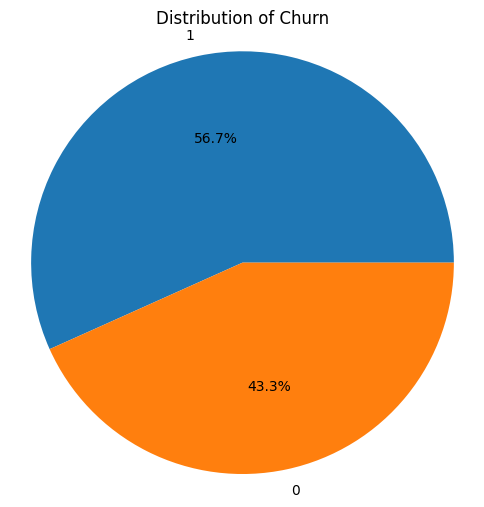

In [23]:
counts = df_train['Churn'].value_counts()
labels = counts.index
sizes = counts.values

plt.figure(figsize=(6,6))
plt.pie(
    sizes, labels=labels, autopct='%1.1f%%',
)
plt.title("Distribution of Churn")
plt.axis('equal')
plt.show()

#### Test Dataset

In [24]:
df_test['Churn']

,Churn
0,1
1,0
2,0
3,0
4,0
...,...
64369,1
64370,1
64371,1
64372,1


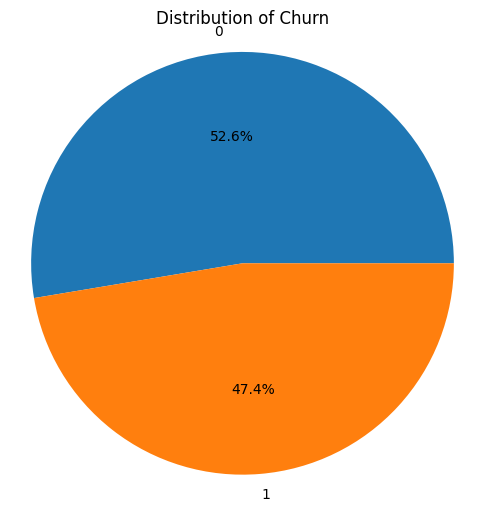

In [25]:
counts = df_test['Churn'].value_counts()
labels = counts.index
sizes = counts.values

plt.figure(figsize=(6,6))
plt.pie(
    sizes, labels=labels, autopct='%1.1f%%',
)
plt.title("Distribution of Churn")
plt.axis('equal')
plt.show()

### Check Numeric Columns

In [26]:
num_cols = df_train.select_dtypes(['int64', 'float64']).columns
num_cols

Index(['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

#### Train Dataset

##### Histogram + KDE

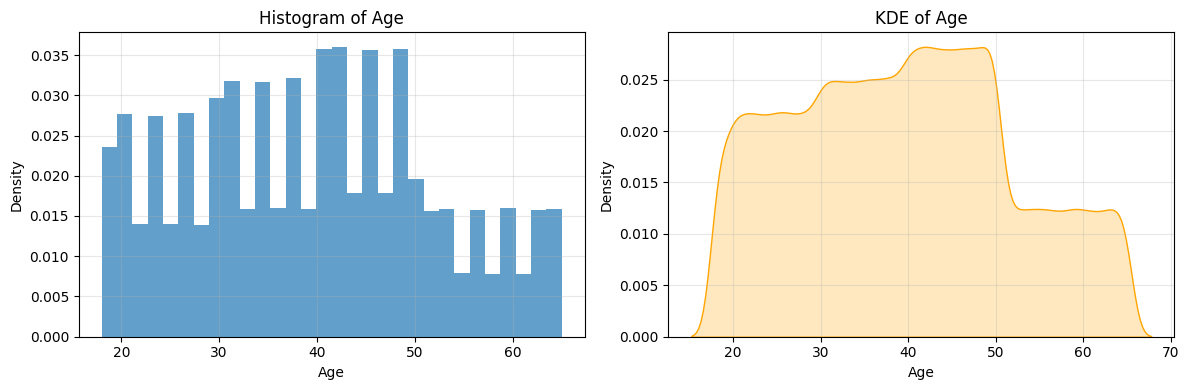

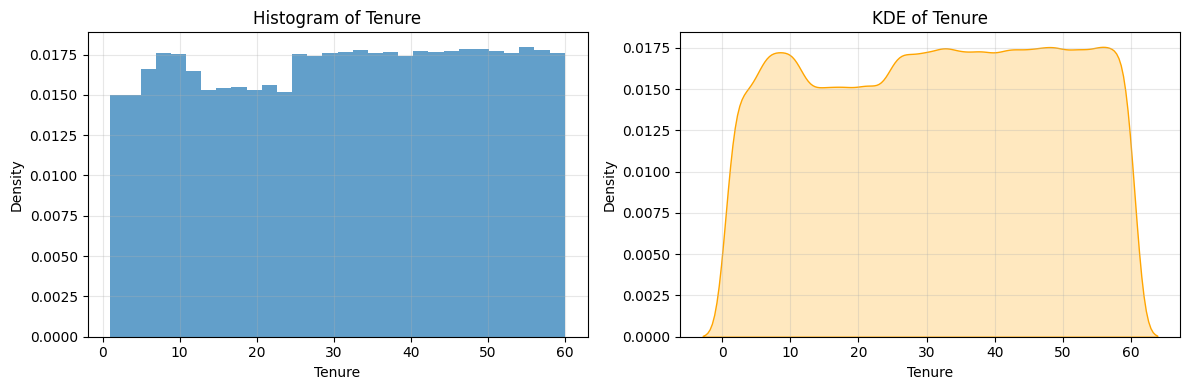

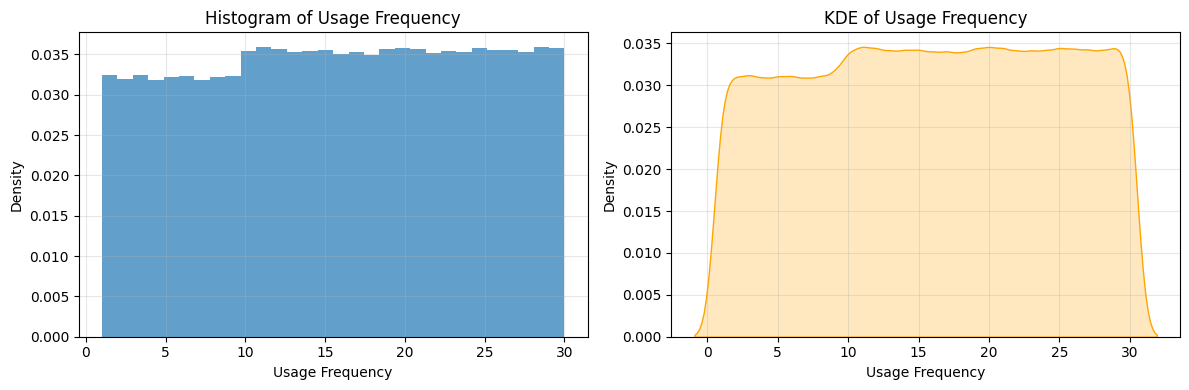

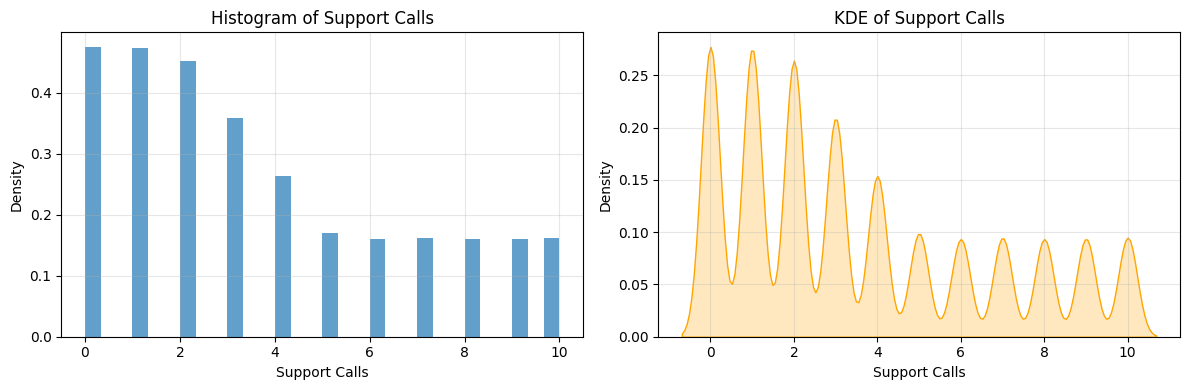

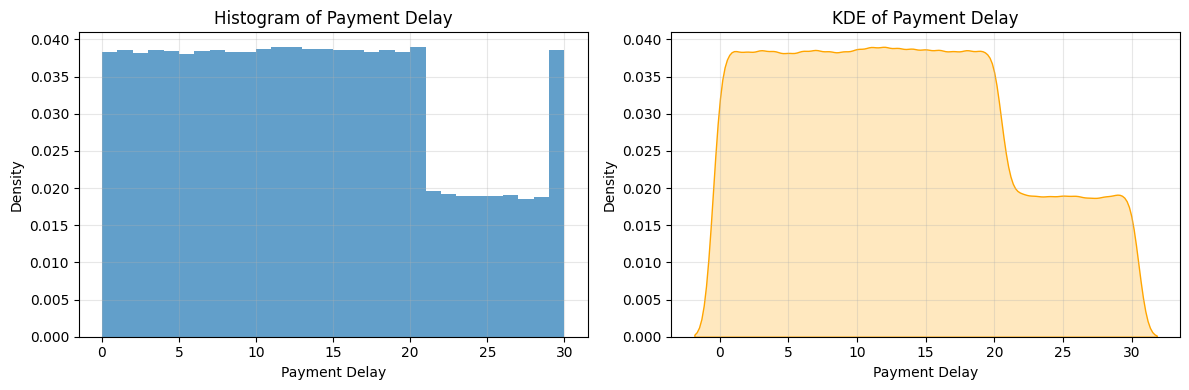

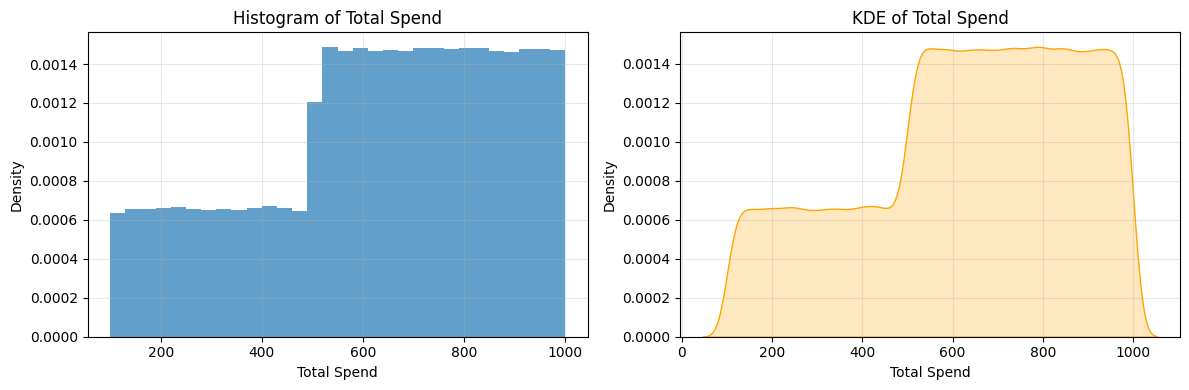

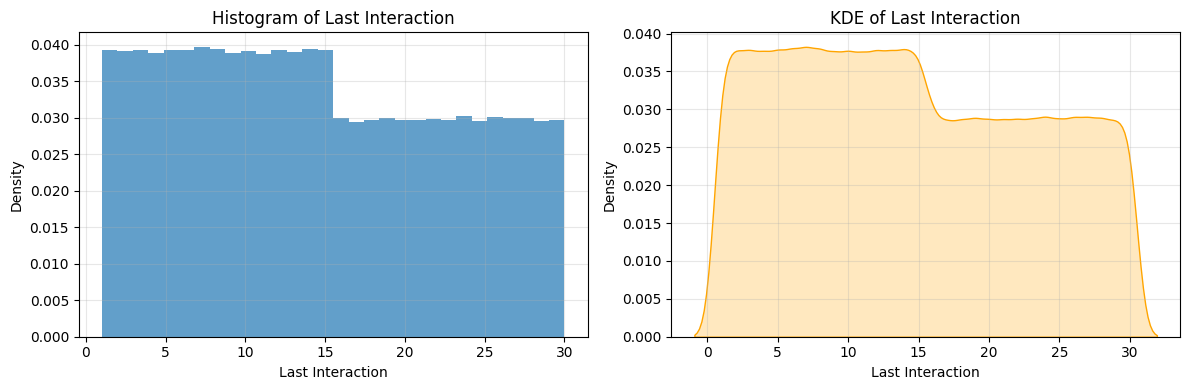

In [27]:
for col in num_cols[:-1]:
    data = df_train[col]
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Histogram
    axes[0].hist(data, bins=30, density=True, alpha=0.7)
    axes[0].set_title(f"Histogram of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Density")
    axes[0].grid(alpha=0.3)

    # KDE
    sns.kdeplot(data, fill=True, ax=axes[1], color='orange')
    axes[1].set_title(f"KDE of {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Density")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

##### Boxplot + Violinplot

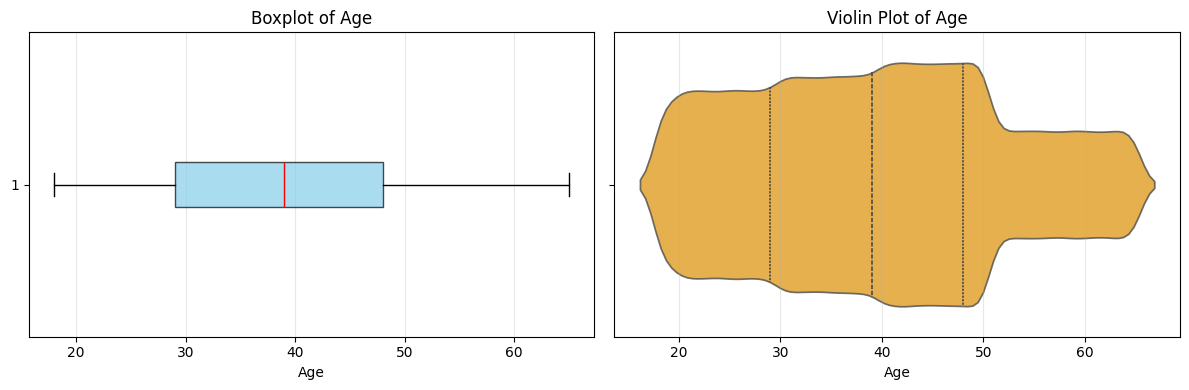

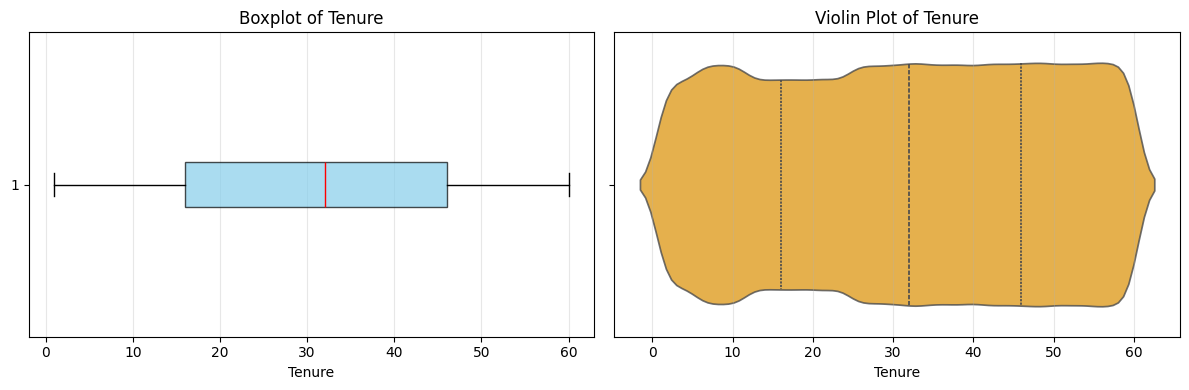

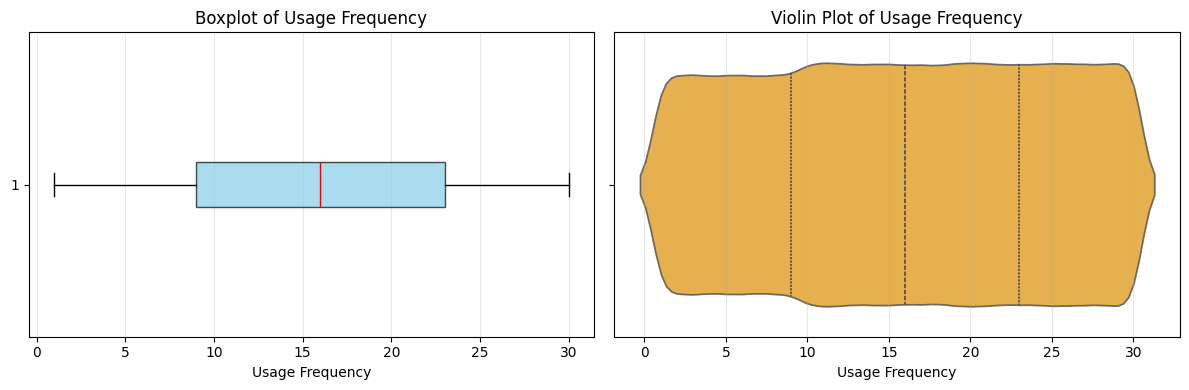

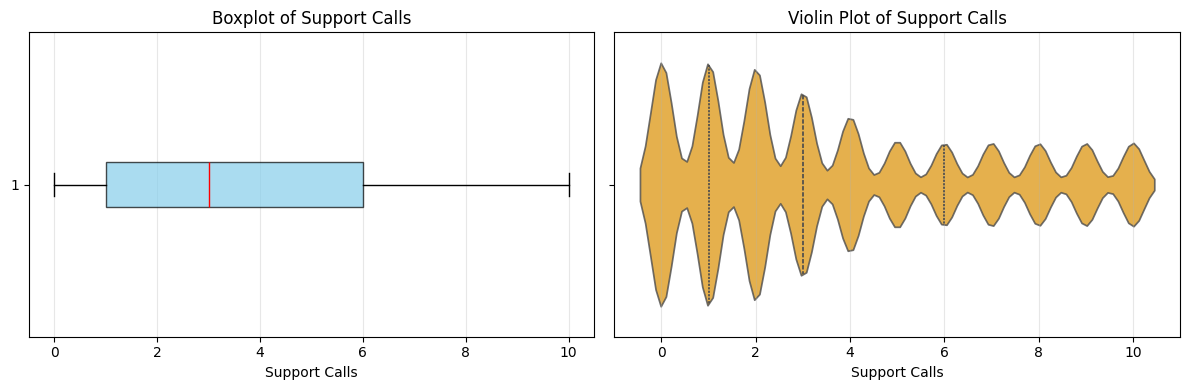

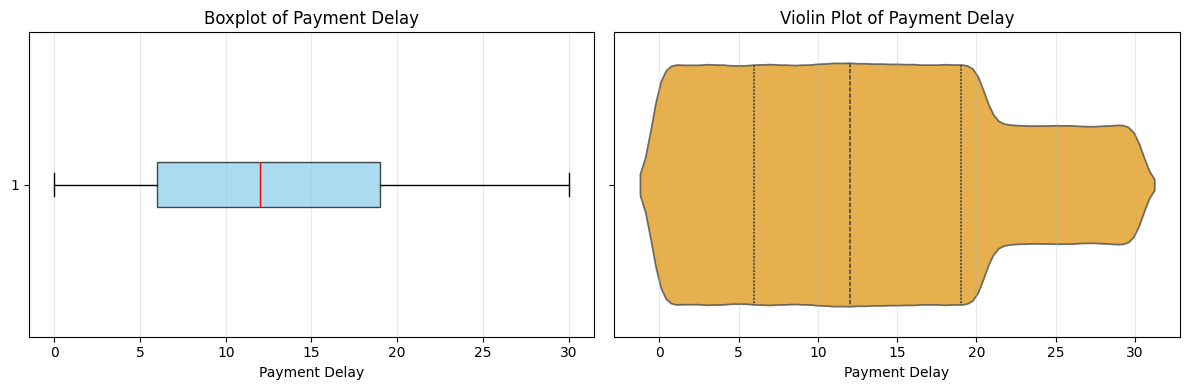

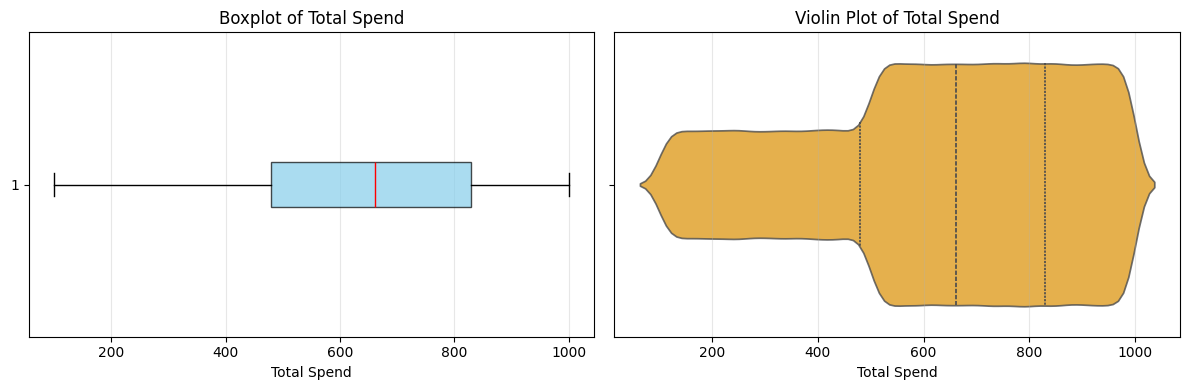

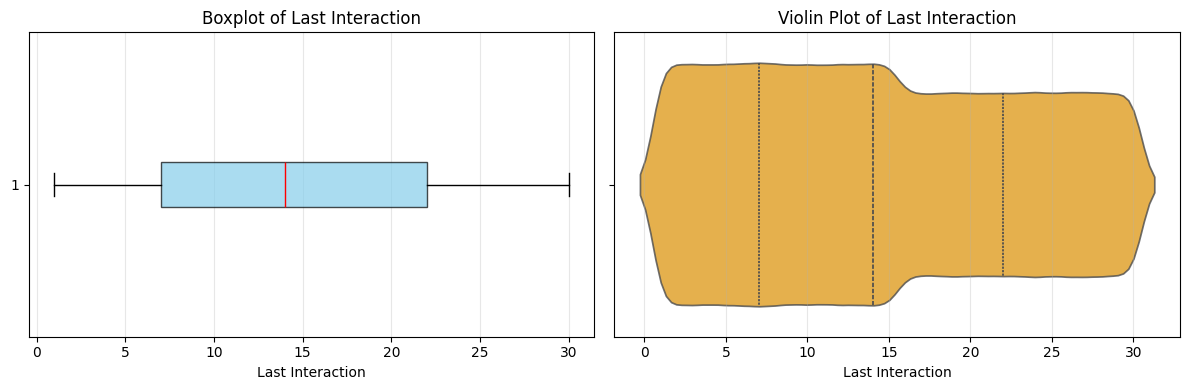

In [28]:
for col in num_cols[:-1]:
    data = df_train[col]

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Boxplot
    axes[0].boxplot(
        data,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='skyblue', alpha=0.7),
        medianprops=dict(color='red')
    )
    axes[0].set_title(f"Boxplot of {col}")
    axes[0].set_xlabel(col)
    axes[0].grid(axis='x', alpha=0.3)

    # Violin Plot
    sns.violinplot(
        x=data,
        ax=axes[1],
        inner='quartile',
        color='orange',
        alpha=0.8
    )
    axes[1].set_title(f"Violin Plot of {col}")
    axes[1].set_xlabel(col)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


#### Test Dataset

##### Histogram + KDE

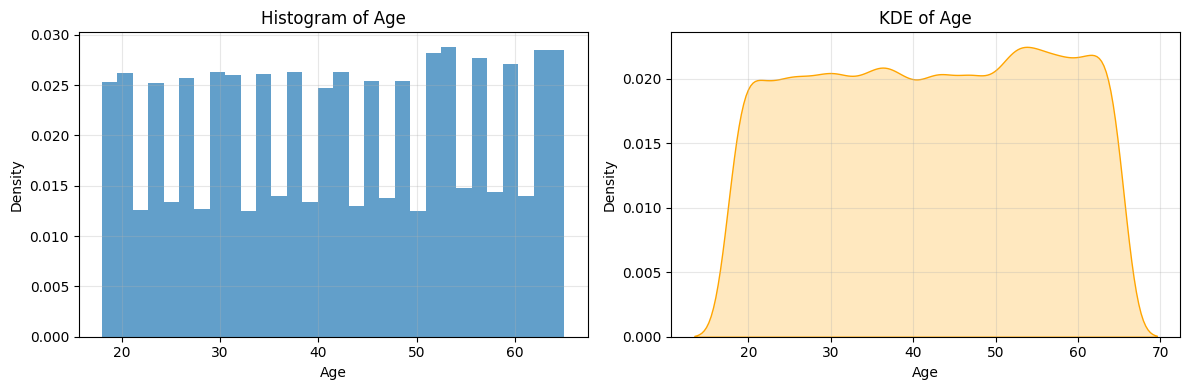

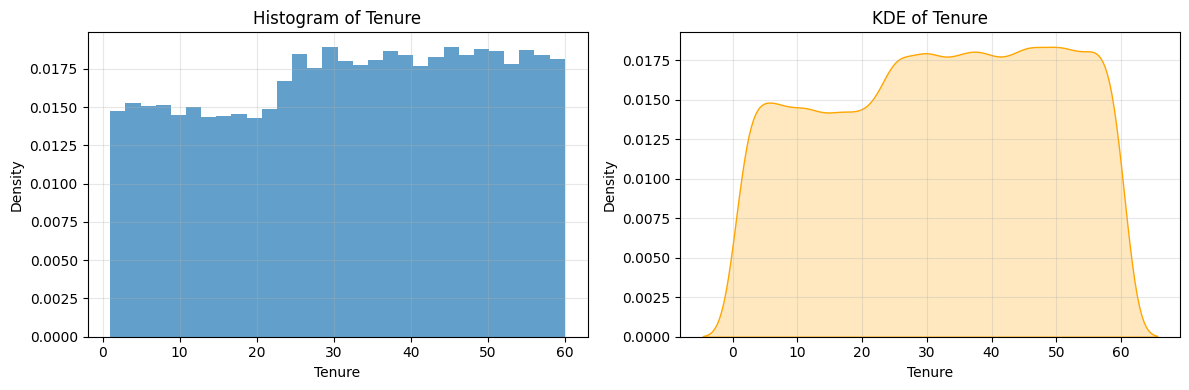

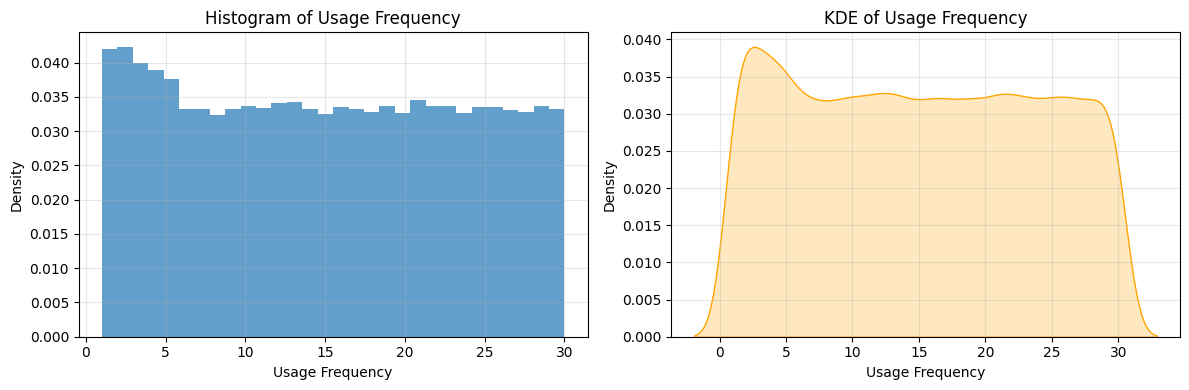

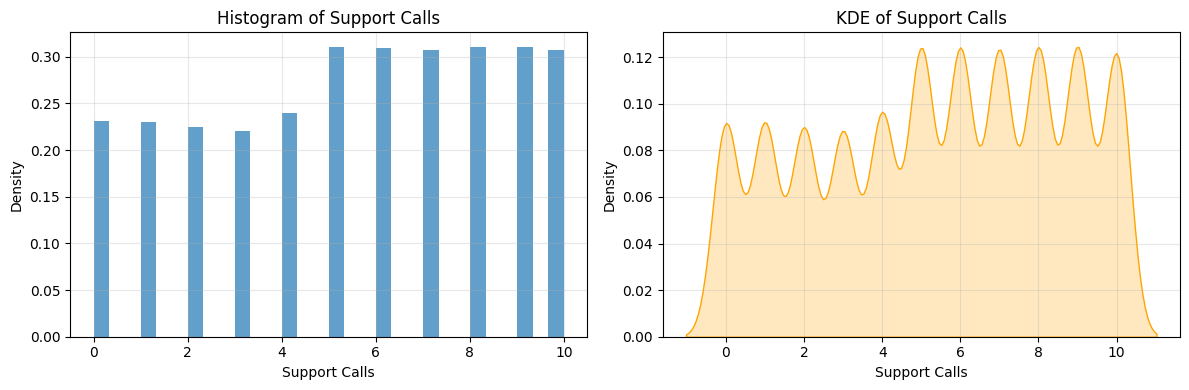

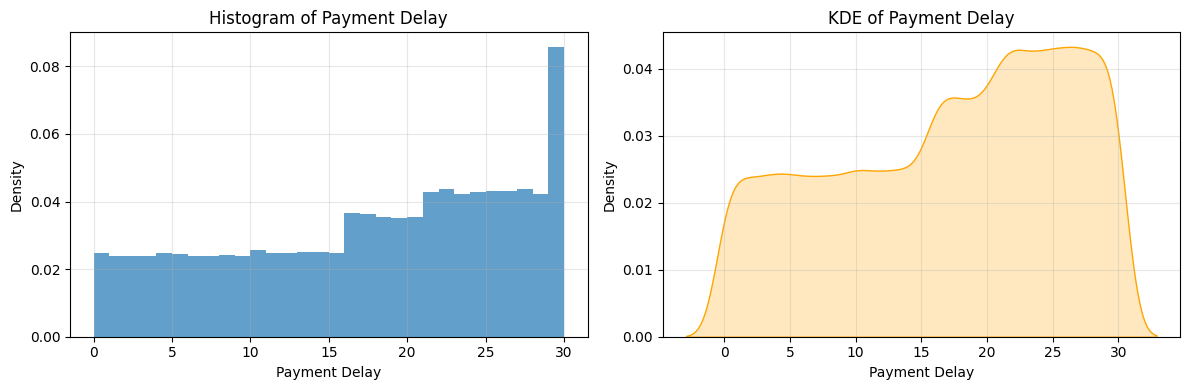

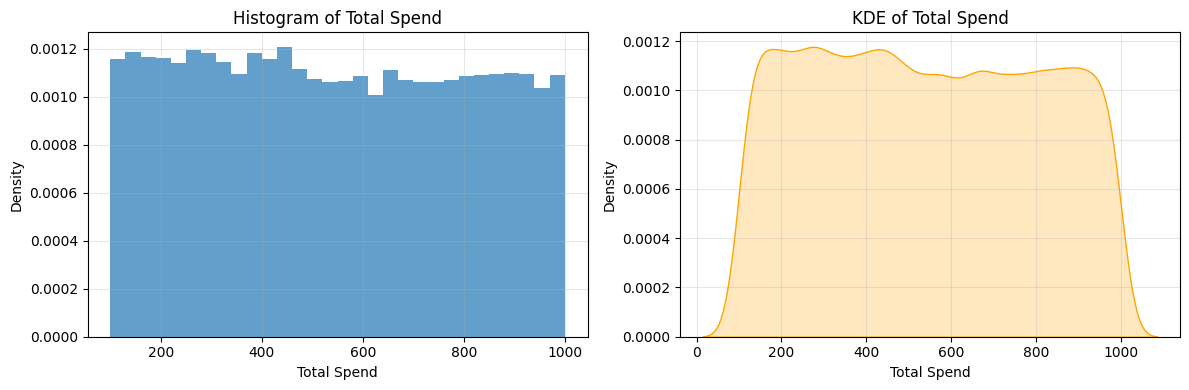

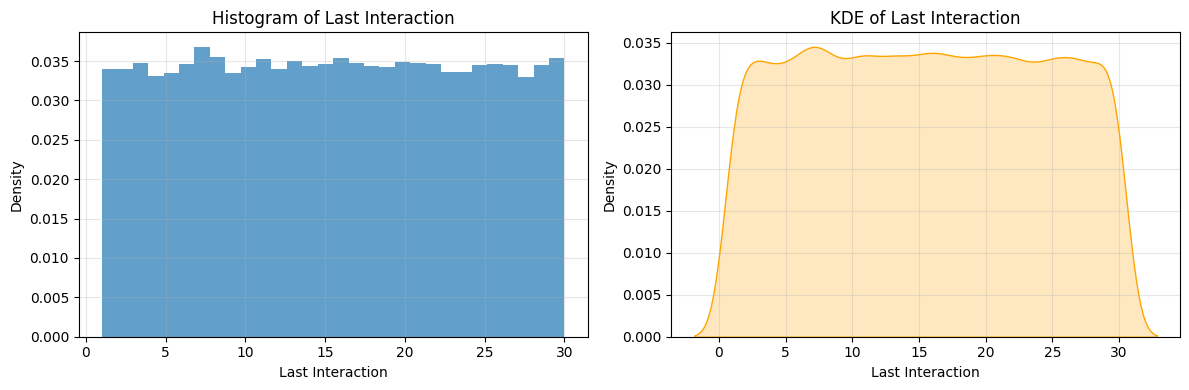

In [29]:
for col in num_cols[:-1]:
    data = df_test[col]
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Histogram
    axes[0].hist(data, bins=30, density=True, alpha=0.7)
    axes[0].set_title(f"Histogram of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Density")
    axes[0].grid(alpha=0.3)

    # KDE
    sns.kdeplot(data, fill=True, ax=axes[1], color='orange')
    axes[1].set_title(f"KDE of {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Density")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

##### Boxplot + Violinplot

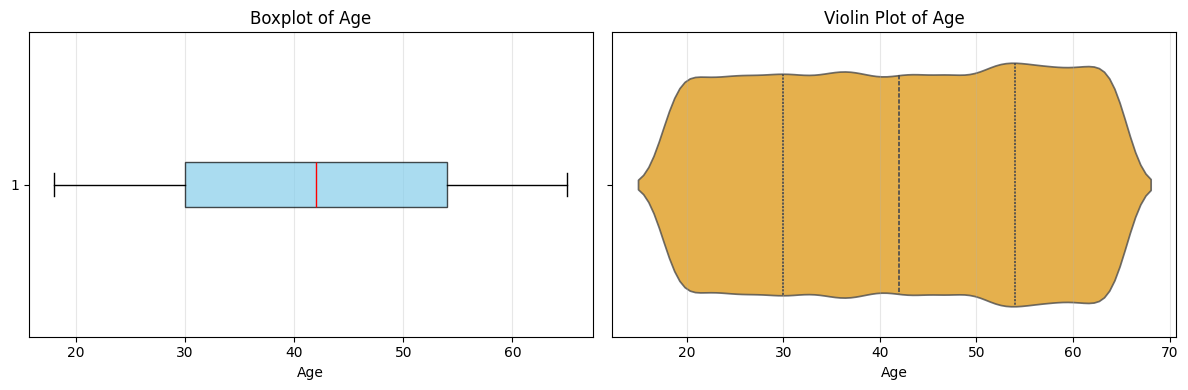

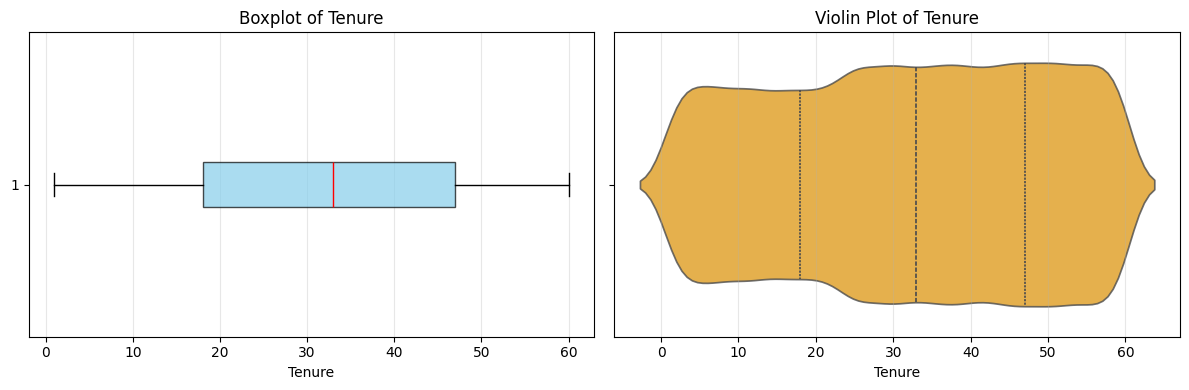

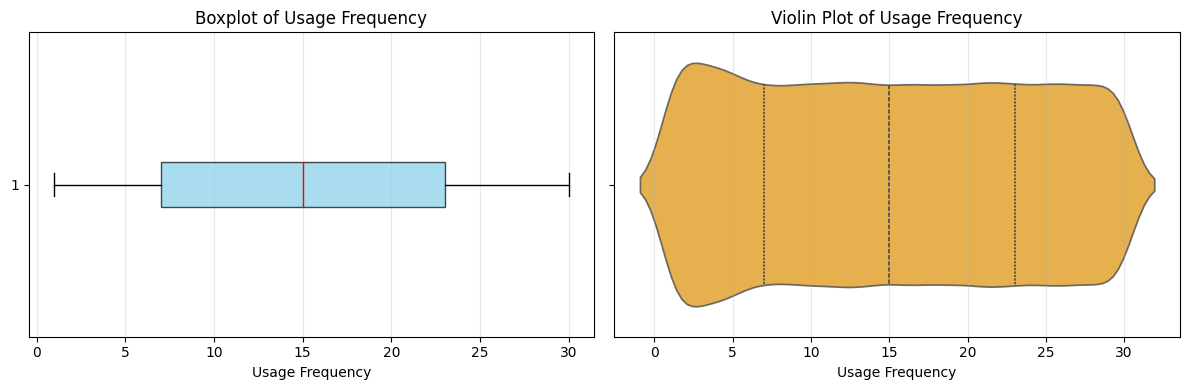

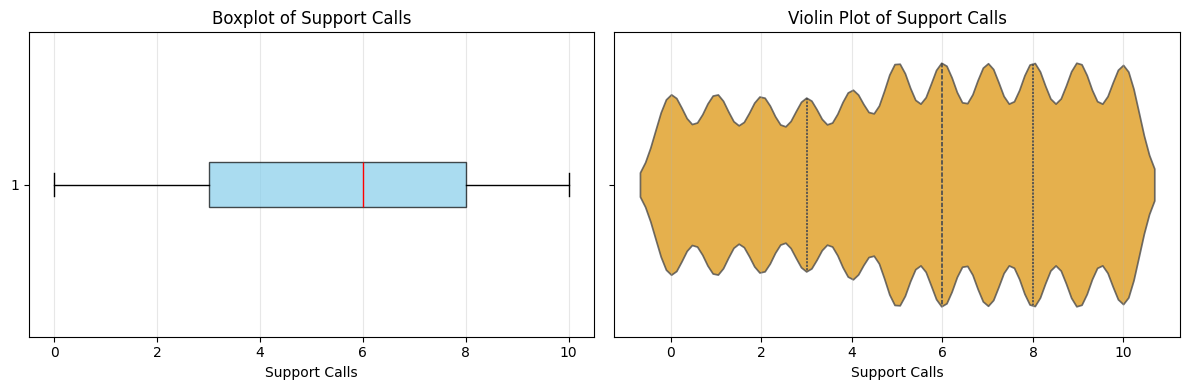

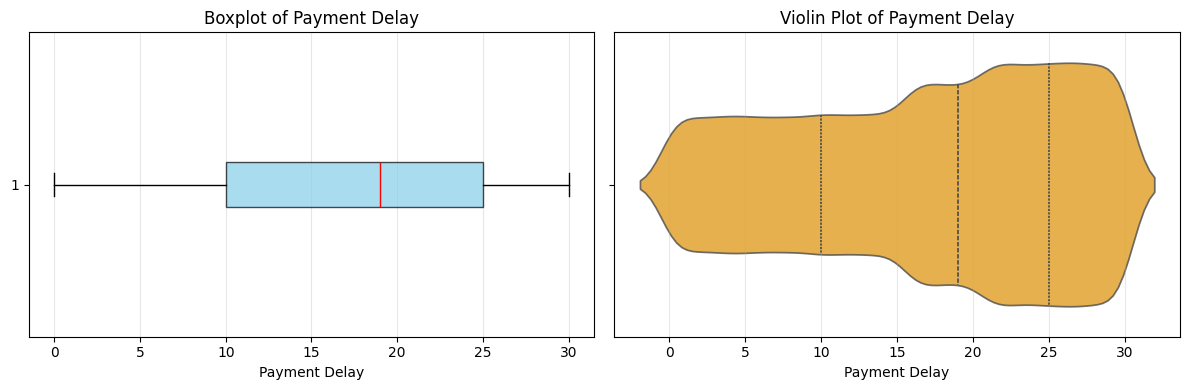

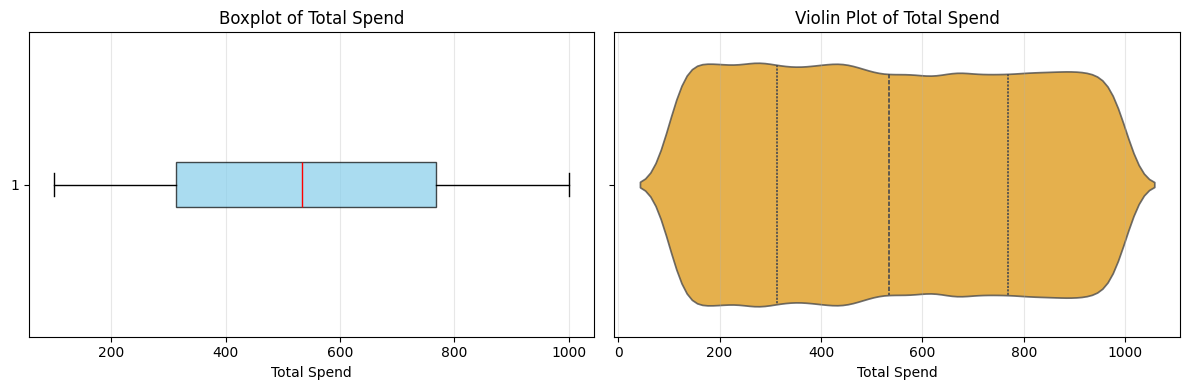

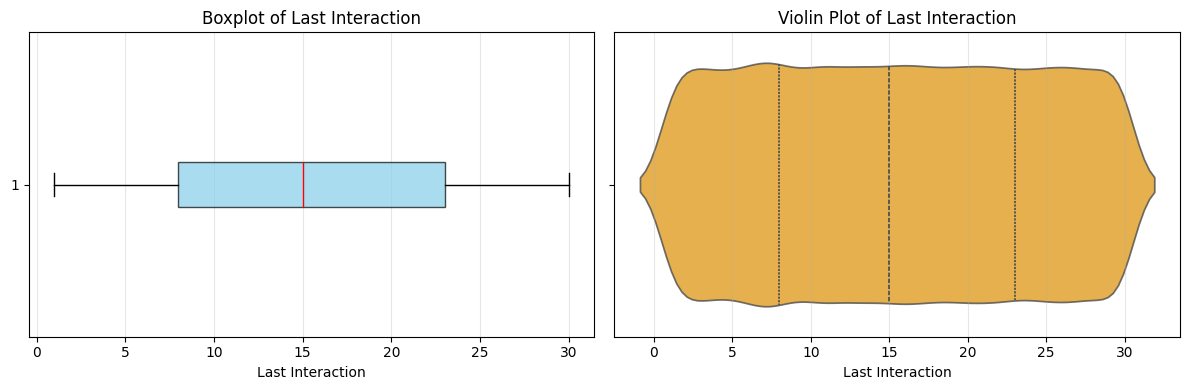

In [30]:
for col in num_cols[:-1]:
    data = df_test[col]

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Boxplot
    axes[0].boxplot(
        data,
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='skyblue', alpha=0.7),
        medianprops=dict(color='red')
    )
    axes[0].set_title(f"Boxplot of {col}")
    axes[0].set_xlabel(col)
    axes[0].grid(axis='x', alpha=0.3)

    # Violin Plot
    sns.violinplot(
        x=data,
        ax=axes[1],
        inner='quartile',
        color='orange',
        alpha=0.8
    )
    axes[1].set_title(f"Violin Plot of {col}")
    axes[1].set_xlabel(col)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


#### Churn Rate Bar Chart

In [31]:
churn_rate = (df_train
    .groupby('Support Calls')['Churn']
    .mean()
    .reset_index()
)

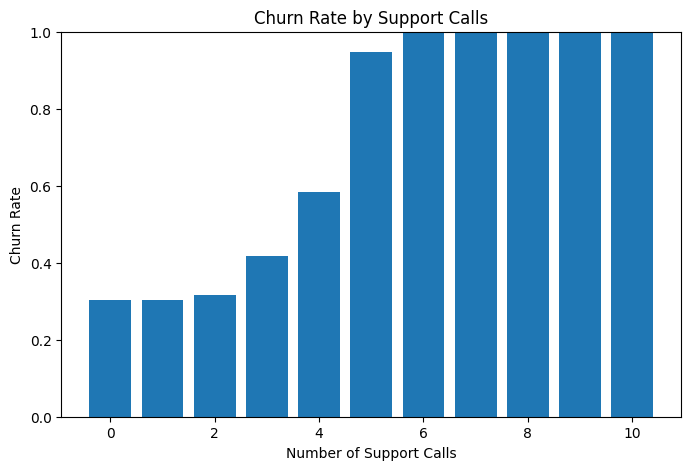

In [32]:
plt.figure(figsize=(8,5))
plt.bar(churn_rate['Support Calls'], churn_rate['Churn'])

plt.xlabel("Number of Support Calls")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Support Calls")
plt.ylim(0,1)

plt.show()

In [33]:
churn_rate = (df_test
    .groupby('Support Calls')['Churn']
    .mean()
    .reset_index()
)

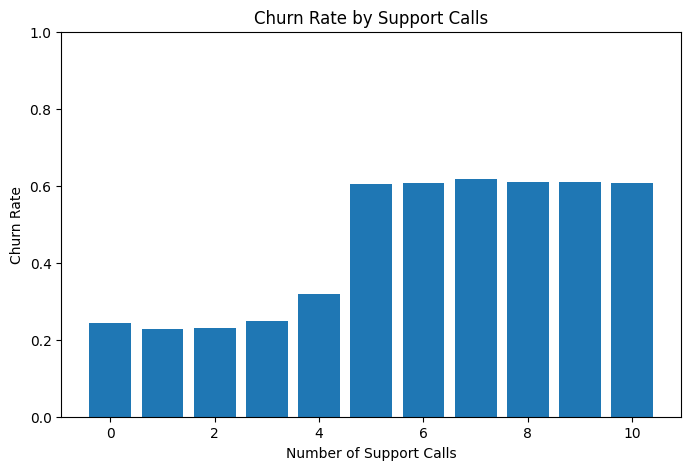

In [34]:
plt.figure(figsize=(8,5))
plt.bar(churn_rate['Support Calls'], churn_rate['Churn'])

plt.xlabel("Number of Support Calls")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Support Calls")
plt.ylim(0,1)

plt.show()

#### Correlation Matrix

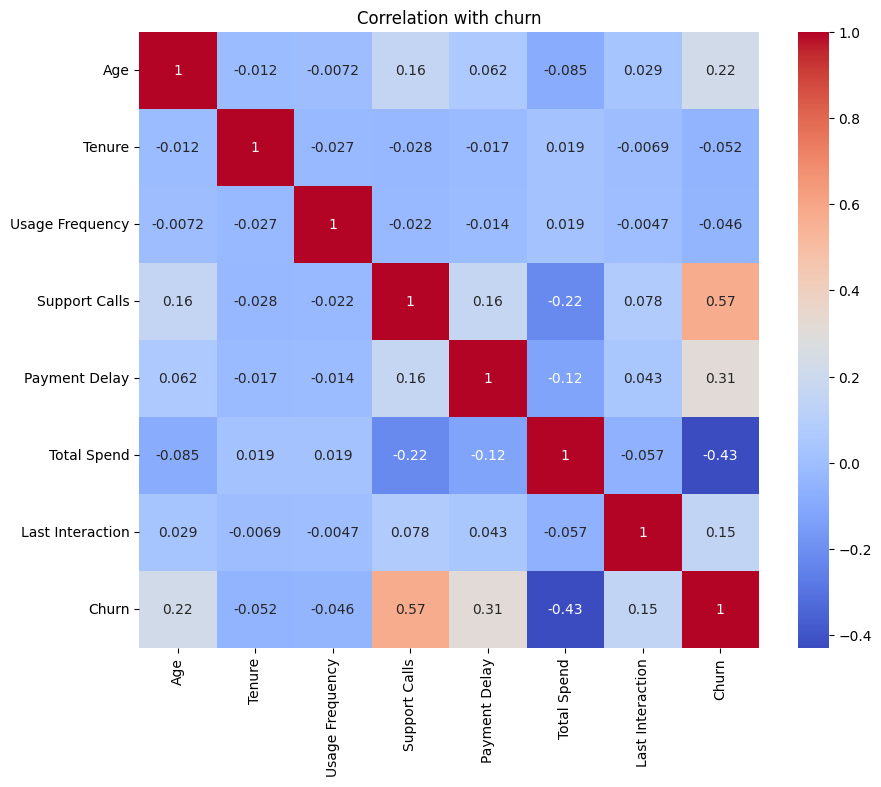

In [35]:
corr = df_train[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation with churn')
plt.show()

### Check Categorical Columns

#### Train Dataset

In [36]:
cat_cols = df_train.select_dtypes(['object']).columns
cat_cols

Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')

In [37]:
for col in cat_cols:
    print(f'\n')
    print(df_train[col].value_counts())



Gender
Male      250252
Female    190580
Name: count, dtype: int64


Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64


Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


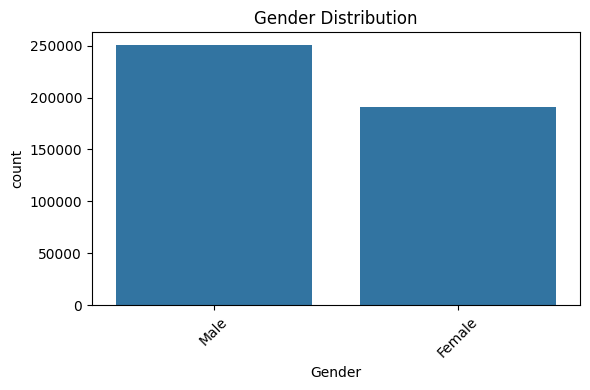

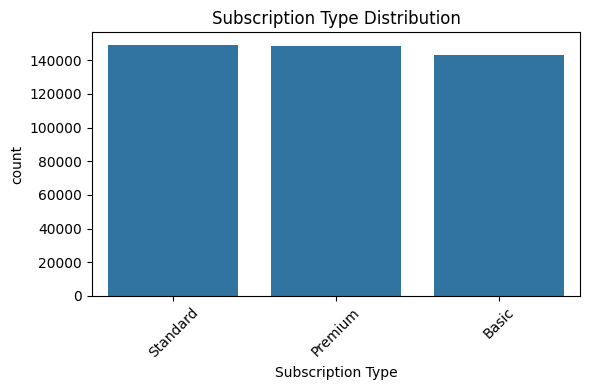

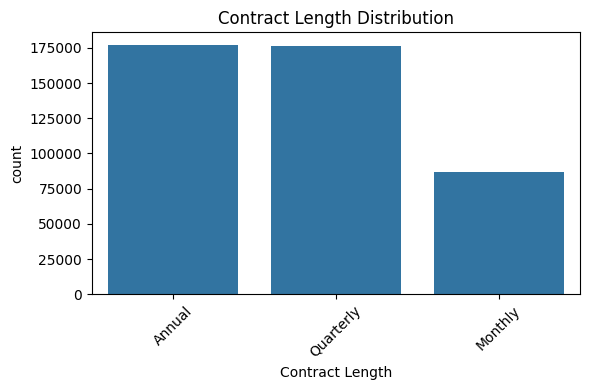

In [38]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df_train[col],
                  order=df_train[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Test Dataset

In [39]:
cat_cols = df_test.select_dtypes(['object']).columns
cat_cols

Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')

In [40]:
for col in cat_cols:
    print(df_test[col].value_counts())

Gender
Female    34353
Male      30021
Name: count, dtype: int64
Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64
Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64


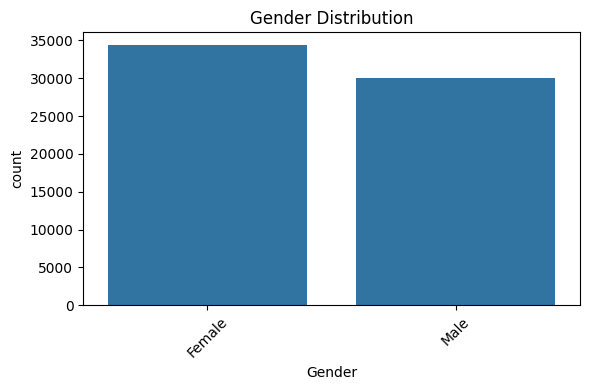

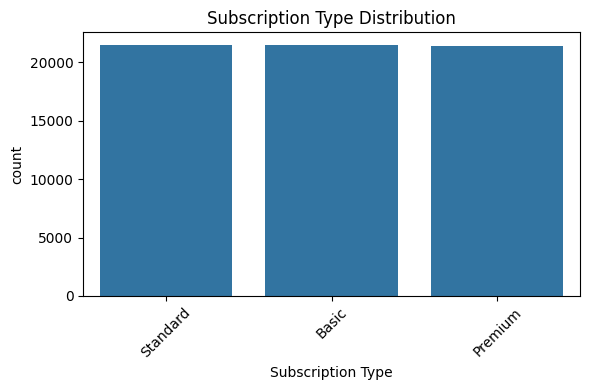

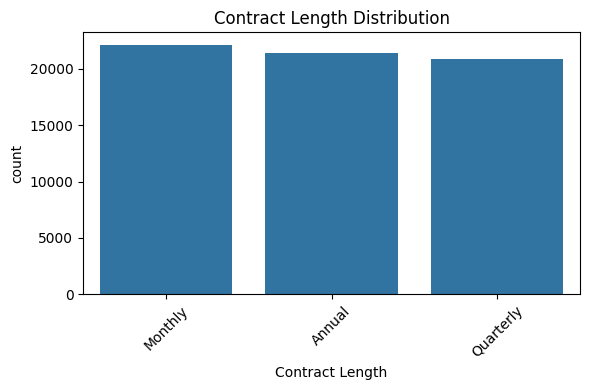

In [41]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df_test[col],
                  order=df_test[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Check Age Group

In [42]:
df_train['Age_Group'] = pd.cut(df_train['Age'],
                        bins=[17, 25, 35, 45, 55, 65],
                        labels=['18-25', '26-35', '36-45', '46-55', '56-65'])

In [43]:
df_temp = df_train.groupby('Age_Group')['Churn'].mean().reset_index()
df_temp['Churn_Rate'] = df_temp['Churn'] * 1

df_temp = df_train.groupby(['Age_Group', 'Subscription Type'], observed=False)['Churn'].mean().reset_index()
df_temp['Churn_Rate'] = df_temp['Churn'] * 100

/tmp/ipykernel_3196/3628994546.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_temp = df_train.groupby('Age_Group')['Churn'].mean().reset_index()


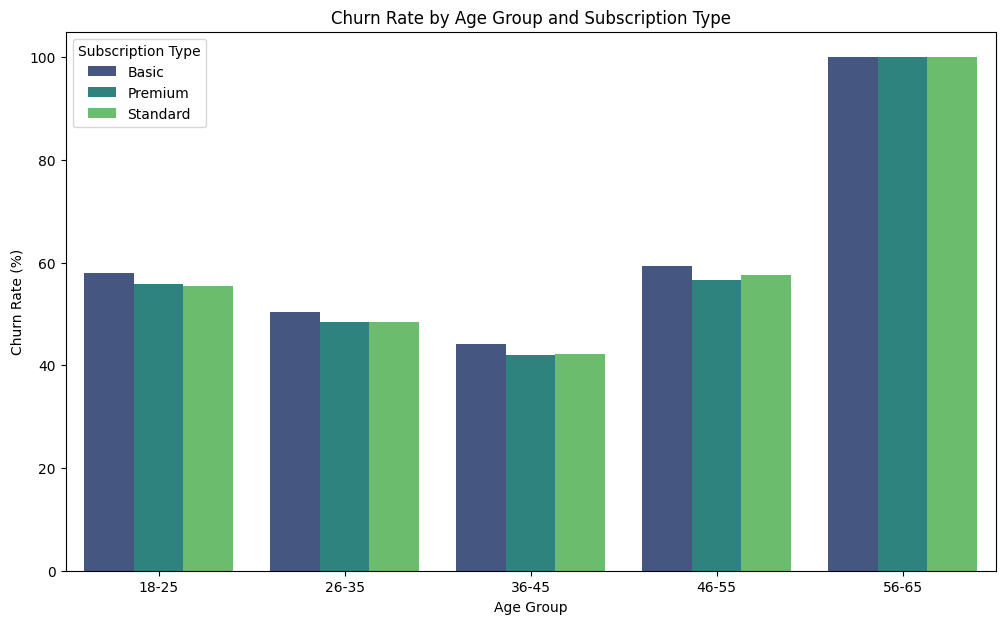

In [44]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Age_Group', y='Churn_Rate', hue='Subscription Type', data=df_temp, palette='viridis')
plt.title('Churn Rate by Age Group and Subscription Type')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Subscription Type')
plt.show()

#### Churn Rate by Customer Tenure

In [45]:
df_train['Tenure_Group'] = pd.cut(df_train['Tenure'],
                          bins=[0, 12, 24, 36, 48, 60],
                          labels=['0-12', '13-24', '25-36', '37-48', '49-60'])

In [46]:
df_t = df_train.groupby('Tenure_Group')['Churn'].mean().reset_index()
df_t['Churn_Rate'] = df_t['Churn'] * 100

/tmp/ipykernel_3196/2489851057.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_t = df_train.groupby('Tenure_Group')['Churn'].mean().reset_index()


/tmp/ipykernel_3196/1498962064.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Tenure_Group', y='Churn_Rate', data=df_t, palette='viridis')


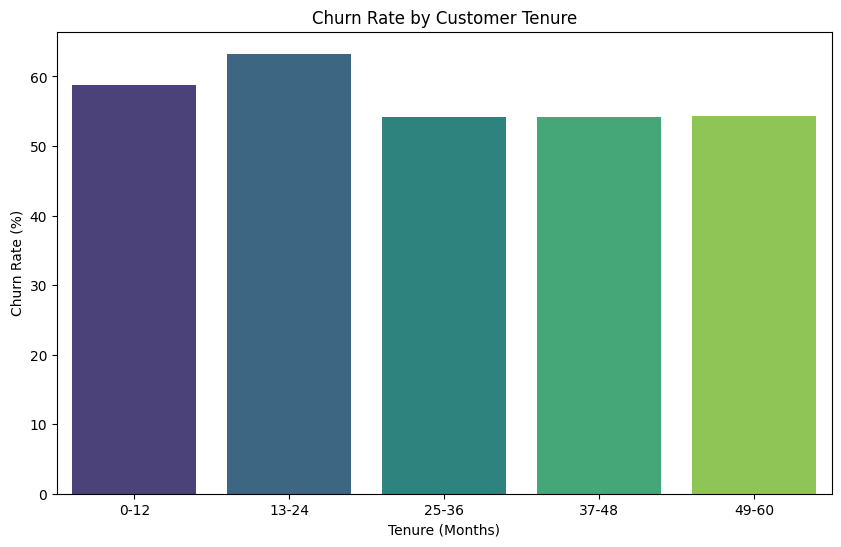

In [47]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Tenure_Group', y='Churn_Rate', data=df_t, palette='viridis')
plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.show()

In [48]:
tenure_monthly_churn = df_train.groupby('Tenure')['Churn'].mean().reset_index()
tenure_monthly_churn['Churn_Rate'] = tenure_monthly_churn['Churn'] * 100

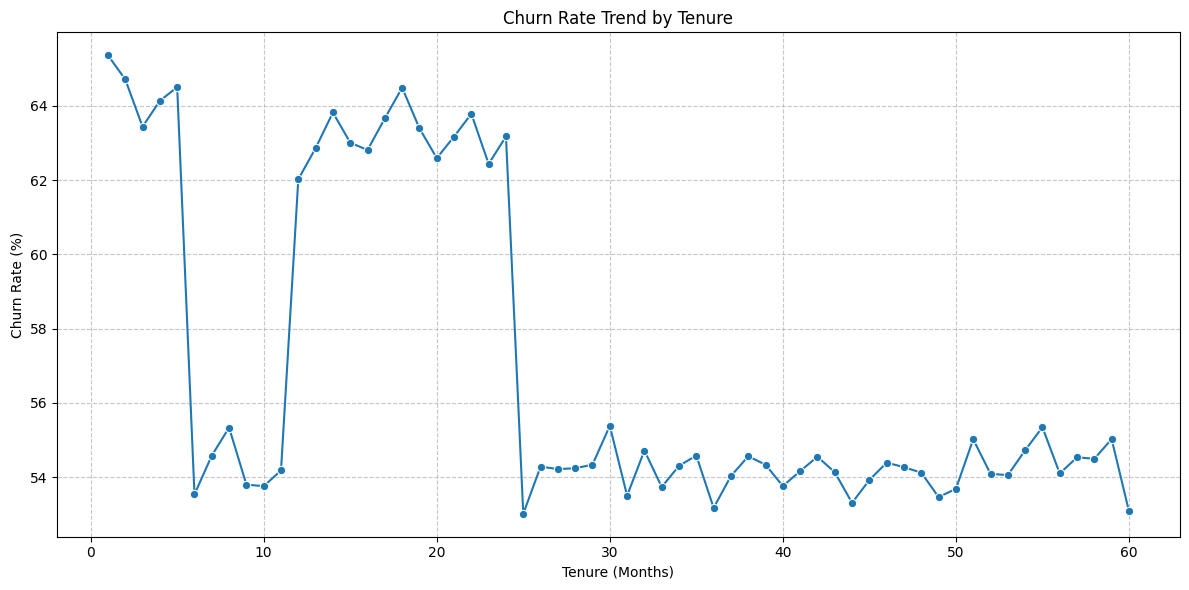

In [49]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Tenure', y='Churn_Rate', data=tenure_monthly_churn, marker='o')
plt.title('Churn Rate Trend by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **🚩 Business Case : Why This Churn Project Matters**

---

#### **1) The Real Problem (Pain Point)** 😟
- The company is losing customers continuously, which directly impacts **Revenue** and **Lifetime Value**.

- Without an early forecasting system, the team acts too late (Reactive instead of Proactive).

---

#### **2) The Most Important Insight from EDA** 🔍
- We discovered a clear **Domain Shift** between the Train and Test (especially in: `Payment Delay`, `Support Calls`, `Total Spend`).

- Simply put: The data the model was trained on is not the same environment it will run in later.

---

#### **3) Business Risks of Ignoring the Problem **💣
- **Incorrect Retention Decisions:** Retention budgets may be allocated to customers who don't need intervention.

- **False Confidence:** High internal accuracy, but poor performance in reality.

- **Increased Churn:** Losing valuable customer segments due to delayed response times.

---

#### **4) Action Plan (Business + Data)** 🛠️
- Feature engineering focuses on actual customer behavior (e.g., Usage Per Tenure).

- Use multiple models and fair comparison (RF/Logistic/XGBoost).

- Select the best model based on practical metrics for the churn class, not just the accuracy number.

---

#### **5) Expected Impact** 🚀
- **Improving Retention Campaign Efficiency** by targeting customers most prone to churn.

- **Reducing intervention costs** by shifting from general campaigns to targeted campaigns.

- **Improving customer experience** through proactive and timely intervention.

---

#### **6) Executive Message** ❤️ This project isn't just a model; it's a decision tool that helps businesses retain the right customers, at the right time, and at the lowest possible cost.

## 4️⃣ Data Preprocessing

### Remove unnecessary columns

In [50]:
df_train = df_train.drop(columns=['Age_Group', 'Tenure_Group'])

### Handle categorical features

In [51]:
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']
df_train_copy = df_train.copy()

In [63]:
label = LabelEncoder()
for col in categorical_cols:
    df_train_copy[col] = label.fit_transform(df_train_copy[col])

In [64]:
df_train.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [54]:
df_train_copy['Usage_Per_Tenure'] = df_train_copy['Usage Frequency'] / (df_train_copy['Tenure'] + 1)
df_train_copy['Spend_Per_Usage'] = df_train_copy['Total Spend'] / (df_train_copy['Usage Frequency'] + 1)
df_train_copy['Spend_Per_Tenure'] = df_train_copy['Total Spend'] / (df_train_copy['Tenure'] + 1)
df_train_copy['Payment_Delay_Ratio'] = df_train_copy['Payment Delay'] / 30
df_train_copy['Engagement_Score'] = (df_train_copy['Usage Frequency'] * df_train_copy['Total Spend']) / 1000

In [65]:
df_test_copy = df_test.copy()
for col in categorical_cols:
    df_test_copy[col] = label.fit_transform(df_test_copy[col])

In [66]:
df_test_copy['Usage_Per_Tenure'] = df_test_copy['Usage Frequency'] / (df_test_copy['Tenure'] + 1)
df_test_copy['Spend_Per_Usage'] = df_test_copy['Total Spend'] / (df_test_copy['Usage Frequency'] + 1)
df_test_copy['Spend_Per_Tenure'] = df_test_copy['Total Spend'] / (df_test_copy['Tenure'] + 1)
df_test_copy['Payment_Delay_Ratio'] = df_test_copy['Payment Delay'] / 30
df_test_copy['Engagement_Score'] = (df_test_copy['Usage Frequency'] * df_test_copy['Total Spend']) / 1000

## 5️⃣ Split Data into Features and Target

In [67]:
numeric_cols = [col for col in df_train.columns if col not in categorical_cols + ['Churn']]
engineered_features = ['Usage_Per_Tenure', 'Spend_Per_Usage', 'Spend_Per_Tenure',
                      'Payment_Delay_Ratio', 'Engagement_Score']

features_to_use = numeric_cols + categorical_cols + engineered_features
print(f"\nFeatures to use: {features_to_use}")


Features to use: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Gender', 'Subscription Type', 'Contract Length', 'Usage_Per_Tenure', 'Spend_Per_Usage', 'Spend_Per_Tenure', 'Payment_Delay_Ratio', 'Engagement_Score']


In [68]:
X = df_train_copy[features_to_use]
y = df_train_copy['Churn']

# ✅ Fix: keep external test separate — don't let train_test_split overwrite it
X_external_test = df_test_copy[features_to_use]
y_external_test = df_test_copy['Churn']


## 6️⃣ Split Data into Train and Test Sets

In [69]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, External Test size: {X_external_test.shape[0]}')


Train size: 352665, Val size: 88167, External Test size: 64374


## 7️⃣ Modeling

### Random Forest

In [70]:
rf_model = RandomForestClassifier(
    n_estimators=90,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=50,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)


📊 Classification Report — Cross-Validated (Train):
              precision    recall  f1-score   support

    No Churn       0.91      0.99      0.95    152666
       Churn       0.99      0.92      0.96    199999

    accuracy                           0.95    352665
   macro avg       0.95      0.96      0.95    352665
weighted avg       0.96      0.95      0.95    352665



<Figure size 800x600 with 0 Axes>

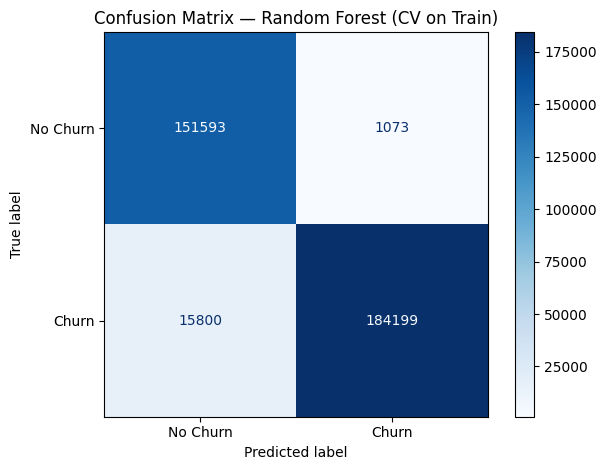

In [71]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(rf_model, X_train, y_train, cv=cv)

print("\n📊 Classification Report — Cross-Validated (Train):")
print(classification_report(y_train, y_pred_cv, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_train, y_pred_cv)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Random Forest (CV on Train)')
plt.tight_layout()
plt.show()

📋 Validation Set Evaluation — Random Forest:
              precision    recall  f1-score   support

    No Churn       0.91      0.99      0.95     38167
       Churn       0.99      0.92      0.96     50000

    accuracy                           0.95     88167
   macro avg       0.95      0.96      0.95     88167
weighted avg       0.96      0.95      0.95     88167



<Figure size 800x600 with 0 Axes>

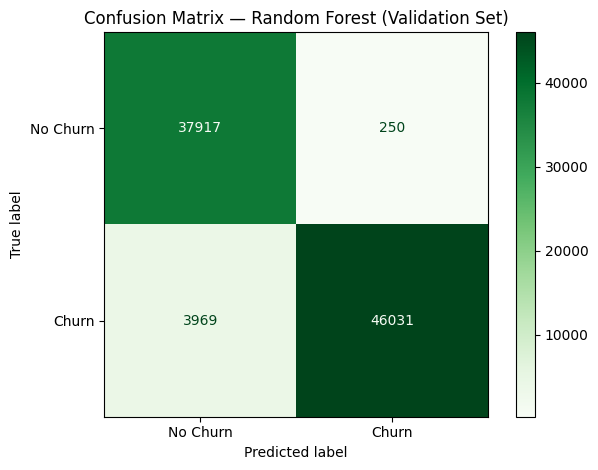

In [72]:
rf_model.fit(X_train, y_train)
val_preds_rf = rf_model.predict(X_val)

print("📋 Validation Set Evaluation — Random Forest:")
print(classification_report(y_val, val_preds_rf, target_names=['No Churn', 'Churn']))

cm_val = confusion_matrix(y_val, val_preds_rf)
plt.figure(figsize=(8, 6))
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['No Churn', 'Churn'])
disp_val.plot(cmap='Greens', values_format='d')
plt.title('Confusion Matrix — Random Forest (Validation Set)')
plt.tight_layout()
plt.show()

📋 External Test Set Evaluation — Random Forest:
              precision    recall  f1-score   support

    No Churn       0.98      0.16      0.27     33881
       Churn       0.52      1.00      0.68     30493

    accuracy                           0.55     64374
   macro avg       0.75      0.58      0.47     64374
weighted avg       0.76      0.55      0.46     64374



<Figure size 800x600 with 0 Axes>

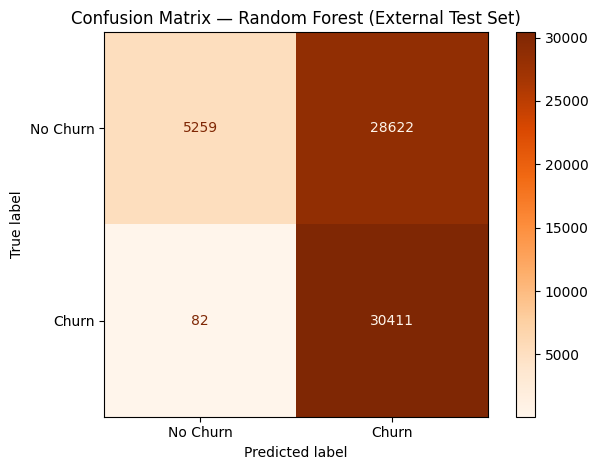

In [73]:
ext_preds_rf = rf_model.predict(X_external_test)

print("📋 External Test Set Evaluation — Random Forest:")
print(classification_report(y_external_test, ext_preds_rf, target_names=['No Churn', 'Churn']))

cm_ext = confusion_matrix(y_external_test, ext_preds_rf)
plt.figure(figsize=(8, 6))
disp_ext = ConfusionMatrixDisplay(confusion_matrix=cm_ext, display_labels=['No Churn', 'Churn'])
disp_ext.plot(cmap='Oranges', values_format='d')
plt.title('Confusion Matrix — Random Forest (External Test Set)')
plt.tight_layout()
plt.show()

### Logistic Regresssion

In [77]:
lr_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', LogisticRegression(
        C=0.1,
        class_weight='balanced',
        max_iter=300,
        random_state=42
    ))
])


Detailed Classification Report (Cross-Validated):
              precision    recall  f1-score   support

    No Churn       0.80      0.88      0.84    152666
       Churn       0.90      0.83      0.87    199999

    accuracy                           0.85    352665
   macro avg       0.85      0.86      0.85    352665
weighted avg       0.86      0.85      0.85    352665



<Figure size 800x600 with 0 Axes>

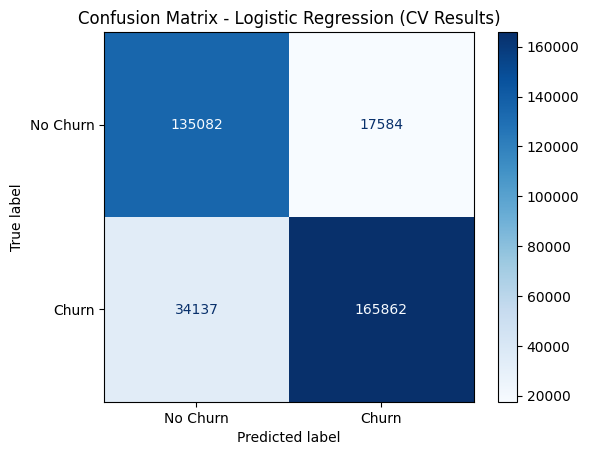

In [78]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(lr_pipeline, X_train, y_train, cv=cv)

print("\nDetailed Classification Report (Cross-Validated):")
print(classification_report(y_train, y_pred, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression (CV Results)')
plt.show()

📋 Validation Set Evaluation — Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.80      0.88      0.84     38167
       Churn       0.90      0.83      0.86     50000

    accuracy                           0.85     88167
   macro avg       0.85      0.86      0.85     88167
weighted avg       0.86      0.85      0.85     88167



<Figure size 800x600 with 0 Axes>

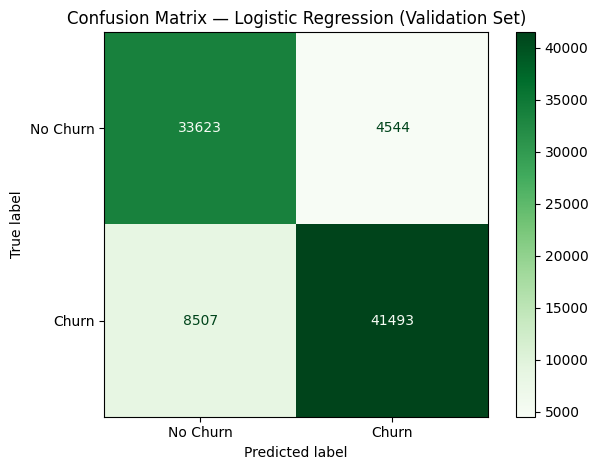

In [79]:
lr_pipeline.fit(X_train, y_train)
val_preds_lr = lr_pipeline.predict(X_val)

print("📋 Validation Set Evaluation — Logistic Regression:")
print(classification_report(y_val, val_preds_lr, target_names=['No Churn', 'Churn']))

cm_val = confusion_matrix(y_val, val_preds_lr)
plt.figure(figsize=(8, 6))
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['No Churn', 'Churn'])
disp_val.plot(cmap='Greens', values_format='d')
plt.title('Confusion Matrix — Logistic Regression (Validation Set)')
plt.tight_layout()
plt.show()

📋 External Test Set Evaluation — Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.93      0.26      0.41     33881
       Churn       0.54      0.98      0.70     30493

    accuracy                           0.60     64374
   macro avg       0.73      0.62      0.55     64374
weighted avg       0.75      0.60      0.55     64374



<Figure size 800x600 with 0 Axes>

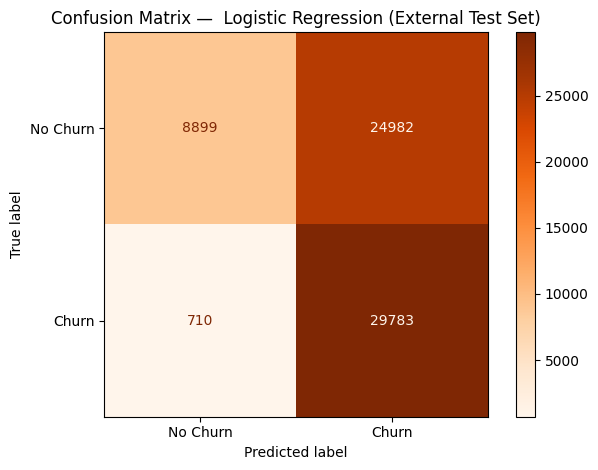

In [80]:
ext_preds_lr = lr_pipeline.predict(X_external_test)

print("📋 External Test Set Evaluation — Logistic Regression:")
print(classification_report(y_external_test, ext_preds_lr, target_names=['No Churn', 'Churn']))

cm_ext = confusion_matrix(y_external_test, ext_preds_lr)
plt.figure(figsize=(8, 6))
disp_ext = ConfusionMatrixDisplay(confusion_matrix=cm_ext, display_labels=['No Churn', 'Churn'])
disp_ext.plot(cmap='Oranges', values_format='d')
plt.title('Confusion Matrix —  Logistic Regression (External Test Set)')
plt.tight_layout()
plt.show()


### XGBoost

In [81]:
xgb_model = XGBClassifier(
    n_estimators=80,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=1,
    reg_alpha=2.0,
    reg_lambda=2.0,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss'
)


Detailed Classification Report (Cross-Validated):
              precision    recall  f1-score   support

    No Churn       0.91      1.00      0.96    152666
       Churn       1.00      0.93      0.96    199999

    accuracy                           0.96    352665
   macro avg       0.96      0.96      0.96    352665
weighted avg       0.96      0.96      0.96    352665



<Figure size 800x600 with 0 Axes>

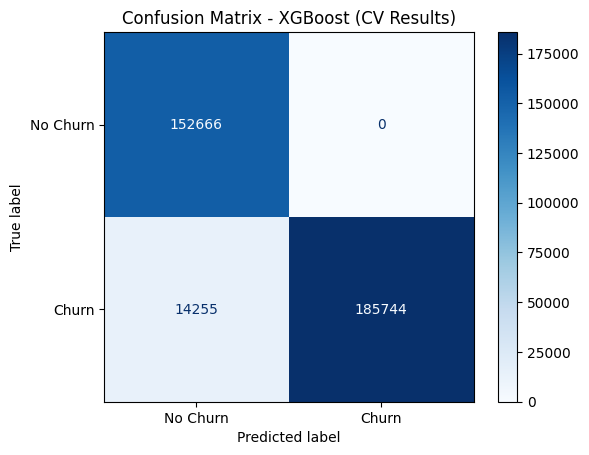

In [82]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(xgb_model, X_train, y_train, cv=cv)

print("\nDetailed Classification Report (Cross-Validated):")
print(classification_report(y_train, y_pred, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - XGBoost (CV Results)')
plt.show()

📋 Validation Set Evaluation — XGBoost:
              precision    recall  f1-score   support

    No Churn       0.91      1.00      0.96     38167
       Churn       1.00      0.93      0.96     50000

    accuracy                           0.96     88167
   macro avg       0.96      0.96      0.96     88167
weighted avg       0.96      0.96      0.96     88167



<Figure size 800x600 with 0 Axes>

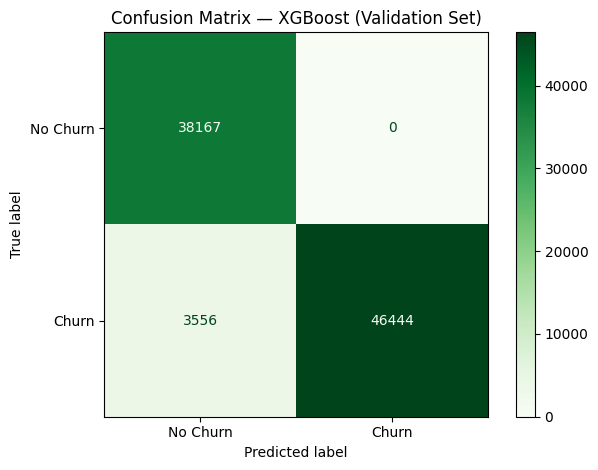

In [84]:
xgb_model.fit(X_train, y_train)
val_preds_xgb = xgb_model.predict(X_val)

print("📋 Validation Set Evaluation — XGBoost:")
print(classification_report(y_val, val_preds_xgb, target_names=['No Churn', 'Churn']))

cm_val = confusion_matrix(y_val, val_preds_xgb)
plt.figure(figsize=(8, 6))
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['No Churn', 'Churn'])
disp_val.plot(cmap='Greens', values_format='d')
plt.title('Confusion Matrix — XGBoost (Validation Set)')
plt.tight_layout()
plt.show()


📋 External Test Set Evaluation — XGBoost:
              precision    recall  f1-score   support

    No Churn       0.98      0.14      0.25     33881
       Churn       0.51      1.00      0.68     30493

    accuracy                           0.55     64374
   macro avg       0.75      0.57      0.46     64374
weighted avg       0.76      0.55      0.45     64374



<Figure size 800x600 with 0 Axes>

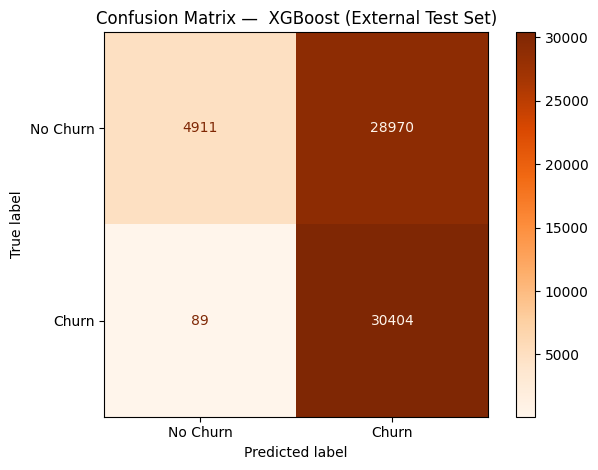

In [85]:
ext_preds_xgb = xgb_model.predict(X_external_test)

print("📋 External Test Set Evaluation — XGBoost:")
print(classification_report(y_external_test, ext_preds_xgb, target_names=['No Churn', 'Churn']))

cm_ext = confusion_matrix(y_external_test, ext_preds_xgb)
plt.figure(figsize=(8, 6))
disp_ext = ConfusionMatrixDisplay(confusion_matrix=cm_ext, display_labels=['No Churn', 'Churn'])
disp_ext.plot(cmap='Oranges', values_format='d')
plt.title('Confusion Matrix —  XGBoost (External Test Set)')
plt.tight_layout()
plt.show()


## 8️⃣ Modeling Summary & Best Model Selection

In [86]:
models = {
    'Random Forest': rf_model,
    'Logistic Regression': lr_pipeline,
    'XGBoost': xgb_model
}

summary_rows = []
for model_name, model in models.items():
    preds = model.predict(X_val)
    summary_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_val, preds),
        'Precision (Churn=1)': precision_score(y_val, preds, pos_label=1, zero_division=0),
        'Recall (Churn=1)': recall_score(y_val, preds, pos_label=1, zero_division=0),
        'F1 (Churn=1)': f1_score(y_val, preds, pos_label=1, zero_division=0)
    })

results_df = pd.DataFrame(summary_rows).sort_values(by='F1 (Churn=1)', ascending=False)
display(results_df)

,Model,Accuracy,Precision (Churn=1),Recall (Churn=1),F1 (Churn=1)
2,XGBoost,0.959667,1.000000,0.92888,0.963129
0,Random Forest,0.952148,0.994598,0.92062,0.956180
1,Logistic Regression,0.851974,0.901297,0.82986,0.864104


In [88]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

joblib.dump(best_model, 'best_model.pkl')

print(f"🏆 Best Model: {best_model_name}")
print("✅ Saved as: best_model.pkl")

🏆 Best Model: XGBoost
✅ Saved as: best_model.pkl


## **Thank You🎀🫶🏻💓**